# 11 · Logistic Regression

Linear regression (notebook 10) predicts a **number**. But many real questions have a **yes/no** answer: did the passenger survive? Did the player come back after 7 days? Will the customer cancel? **Logistic regression** predicts the **probability** of "yes", and tells us how each variable changes it.

**What you will learn here**

1. Why a straight line fails for yes/no outcomes
2. Odds, log-odds and the S-shaped (sigmoid) curve
3. Logistic regression with one variable, fully by hand
4. How the model is fitted with many variables (maximum likelihood, coded from scratch)
5. Reading odds ratios on real data (Titanic: sex, class and age)
6. Checking how good the model is: baseline, confusion matrix, pseudo-R²
7. Logistic regression on an A/B test, and the "bad control" trap

> **Colour guide:** $\color{red}{\text{red}}$ marks a rejected null hypothesis, a warning or a wrong reading. $\color{green}{\text{green}}$ marks a null hypothesis we fail to reject, a passed check or a correct reading.

## The datasets

**1. Titanic** (`data/titanic.csv`), already used in notebooks 04 and 06. Source: [seaborn-data](https://github.com/mwaskom/seaborn-data/blob/master/titanic.csv), the same 891 passengers as the Kaggle Titanic training set. Historical records, free for teaching.

| Column | Meaning |
|---|---|
| `survived` | 1 = survived, 0 = died |
| `sex` | female / male |
| `pclass` | Ticket class: 1 = first, 2 = second, 3 = third |
| `age` | Age in years (missing for 177 passengers) |

**2. Cookie Cats** (`data/cookie_cats.csv`), the mobile game A/B test from the experimentation folder. Source: Tactile Entertainment, published on [Kaggle](https://www.kaggle.com/datasets/yufengsui/mobile-games-ab-testing). 90,189 players.

| Column | Meaning |
|---|---|
| `version` | `gate_30` (control) or `gate_40` (treatment): the level where the first gate appears |
| `sum_gamerounds` | Rounds played in the first 14 days |
| `retention_7` | True if the player came back 7 days after installing |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

BLUE = "#2a78d6"
ORANGE = "#eb6834"
GREEN = "#1baf7a"

titanic = pd.read_csv("../data/titanic.csv")
cookie_cats = pd.read_csv("../data/cookie_cats.csv")
titanic[["survived", "sex", "pclass", "age"]].head()

,survived,sex,pclass,age
0,0,male,3,22.0
1,1,female,1,38.0
2,1,female,3,26.0
3,1,female,1,35.0
4,0,male,3,35.0


---
## 1. Why not a straight line?

Let's try to predict survival (0 or 1) from the fare paid, with an ordinary straight line.

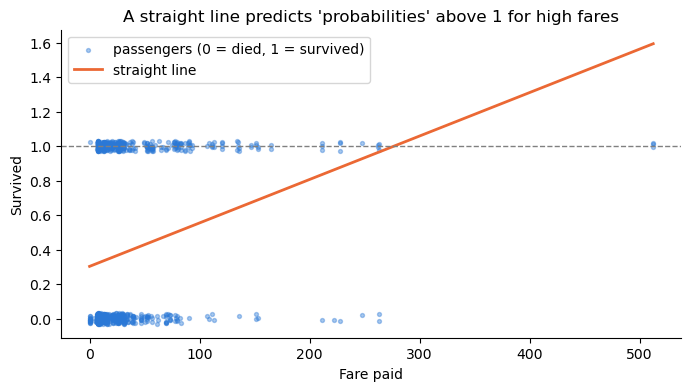

predicted 'probability' at the highest fare: 1.59


In [2]:
line = smf.ols("survived ~ fare", data=titanic).fit()
fare_grid = np.linspace(0, titanic["fare"].max(), 100)

fig, ax = plt.subplots()
ax.scatter(titanic["fare"], titanic["survived"] + np.random.default_rng(0).uniform(-0.03, 0.03, len(titanic)), s=8, color=BLUE, alpha=0.4, label="passengers (0 = died, 1 = survived)")
ax.plot(fare_grid, line.params["Intercept"] + line.params["fare"] * fare_grid, color=ORANGE, linewidth=2, label="straight line")
ax.axhline(1, color="grey", linestyle="--", linewidth=1)
ax.set_title("A straight line predicts 'probabilities' above 1 for high fares")
ax.set_xlabel("Fare paid")
ax.set_ylabel("Survived")
ax.legend()
plt.show()
print(f"predicted 'probability' at the highest fare: {line.params['Intercept'] + line.params['fare'] * titanic['fare'].max():.2f}")

A probability must stay between 0 and 1, but a straight line keeps going. We need a curve that bends and stays inside [0, 1].

---
## 2. Odds, log-odds and the sigmoid

> **Theory.** Three ways to say the same thing:

| Scale | Formula | Range | Example: p = 0.75 |
|---|---|---|---|
| **Probability** | p | 0 to 1 | 0.75 |
| **Odds** | p / (1 − p) | 0 to ∞ | 0.75 / 0.25 = 3 ("3 to 1") |
| **Log-odds** (logit) | log(p / (1 − p)) | −∞ to +∞ | log(3) = 1.10 |

The log-odds can take **any** value, just like a straight line. So logistic regression puts the straight line on the log-odds scale:

$$\log\left(\frac{p}{1 - p}\right) = b_0 + b_1 x$$

and turns it back into a probability with the **sigmoid** function:

$$p = \frac{1}{1 + e^{-(b_0 + b_1 x)}}$$

**How to read a coefficient:** $b_1$ is the change in log-odds when x goes up by 1. That's hard to picture, so we use $e^{b_1}$, the **odds ratio**: the odds get **multiplied** by $e^{b_1}$ for each +1 in x.

| Odds ratio | Meaning |
|---|---|
| > 1 | "yes" becomes more likely |
| = 1 | no effect |
| < 1 | "yes" becomes less likely |

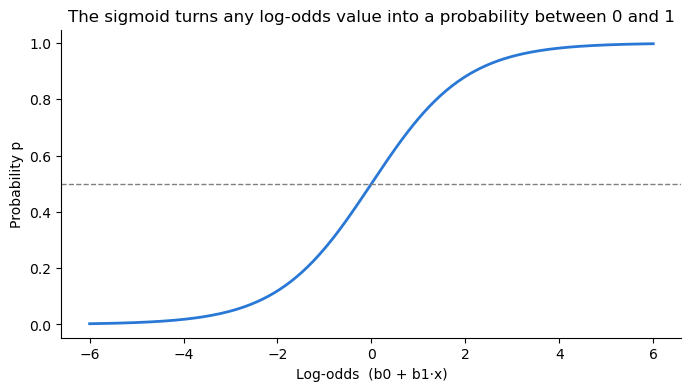

In [3]:
z = np.linspace(-6, 6, 200)
fig, ax = plt.subplots()
ax.plot(z, 1 / (1 + np.exp(-z)), color=BLUE, linewidth=2)
ax.axhline(0.5, color="grey", linestyle="--", linewidth=1)
ax.set_title("The sigmoid turns any log-odds value into a probability between 0 and 1")
ax.set_xlabel("Log-odds  (b0 + b1·x)")
ax.set_ylabel("Probability p")
plt.show()

At log-odds 0 the probability is exactly 0.5. Big positive values go towards 1, big negative values towards 0, and the curve never leaves [0, 1].

---
## 3. One variable, fully by hand

**Question:** how much did being a man change the chance of surviving the Titanic?

With a single yes/no predictor, the logistic model can be solved by hand: the intercept is the log-odds of the reference group (women), and the slope is the **difference** in log-odds between the groups.

**Manual calculation.** From notebook 04: 74.2% of women and 18.9% of men survived.

| | Women | Men |
|---|---|---|
| Survival rate p | 0.742 | 0.189 |
| Odds p / (1 − p) | 0.742 / 0.258 = **2.877** | 0.189 / 0.811 = **0.233** |
| Log-odds | log(2.877) = **1.057** | log(0.233) = **−1.457** |

- $b_0$ = log-odds for women = **1.057**
- $b_1$ = −1.457 − 1.057 = **−2.514**
- Odds ratio = $e^{-2.514}$ = 0.233 / 2.877 = **0.081**

So a man's odds of surviving were about **0.08 times** a woman's, roughly 12 times lower.

In [4]:
survival_rate = titanic.groupby("sex")["survived"].mean()
odds = survival_rate / (1 - survival_rate)
log_odds = np.log(odds)
print(f"by hand    : b0 = {log_odds['female']:.3f}, b1 = {log_odds['male'] - log_odds['female']:.3f}, odds ratio = {odds['male'] / odds['female']:.3f}")

# docs: https://www.statsmodels.org/stable/generated/statsmodels.formula.api.logit.html
sex_model = smf.logit("survived ~ C(sex)", data=titanic).fit(disp=0)
print(f"statsmodels: b0 = {sex_model.params['Intercept']:.3f}, b1 = {sex_model.params['C(sex)[T.male]']:.3f}, odds ratio = {np.exp(sex_model.params['C(sex)[T.male]']):.3f}")

by hand    : b0 = 1.057, b1 = -2.514, odds ratio = 0.081
statsmodels: b0 = 1.057, b1 = -2.514, odds ratio = 0.081


> **Check:** Same numbers by hand and from statsmodels.

---
## 4. Many variables: maximum likelihood

With several variables (or a continuous one like age) there is no simple formula. Instead the model picks the coefficients that make the observed outcomes **most likely**.

> **Theory.** For each passenger the model gives a probability $p_i$. If they survived, we want $p_i$ high. If they died, we want $1 - p_i$ high. The **log-likelihood** adds this up:
>
> $$\ell = \sum_i \big[\, y_i \log(p_i) + (1 - y_i) \log(1 - p_i) \,\big]$$
>
> The best coefficients make $\ell$ as large as possible. (Machine learning calls $-\ell / n$ the **log loss** or **binary cross-entropy**.)

There is no closed formula, so computers climb to the top step by step. The classic method is **Newton's method** (also called IRLS): start at 0, look at the slope and curvature of $\ell$, jump towards the top, repeat. Here it is from scratch in a few lines:

In [5]:
titanic_age = titanic.dropna(subset=["age"]).copy()
print(f"passengers with a known age: {len(titanic_age)} of {len(titanic)}")

X = np.column_stack([
    np.ones(len(titanic_age)),                      # intercept
    (titanic_age["sex"] == "male").astype(float),   # 1 = male
    (titanic_age["pclass"] == 2).astype(float),     # 1 = second class
    (titanic_age["pclass"] == 3).astype(float),     # 1 = third class
    titanic_age["age"].to_numpy(),
])
y = titanic_age["survived"].to_numpy()

b = np.zeros(X.shape[1])
for step in range(1, 11):
    p = 1 / (1 + np.exp(-X @ b))              # current probabilities
    gradient = X.T @ (y - p)                  # slope of the log-likelihood
    hessian = X.T @ (X * (p * (1 - p))[:, None])  # curvature
    b = b + np.linalg.solve(hessian, gradient)    # Newton step
    log_likelihood = (y * np.log(p) + (1 - y) * np.log(1 - p)).sum()
    if step <= 5:
        print(f"step {step}: log-likelihood = {log_likelihood:.2f}")

print("\nfrom scratch:", b.round(4))

passengers with a known age: 714 of 891
step 1: log-likelihood = -494.91
step 2: log-likelihood = -333.93
step 3: log-likelihood = -324.03
step 4: log-likelihood = -323.64
step 5: log-likelihood = -323.64

from scratch: [ 3.777  -2.5228 -1.3098 -2.5806 -0.037 ]


In [6]:
full_model = smf.logit("survived ~ C(sex) + C(pclass) + age", data=titanic_age).fit(disp=0)
print("statsmodels :", full_model.params.to_numpy().round(4))

statsmodels : [ 3.777  -2.5228 -1.3098 -2.5806 -0.037 ]


> **Check:** Our 10-line Newton's method gives the same coefficients as statsmodels. The log-likelihood climbs fast and stops changing after a few steps.

> $\color{red}{\text{Warning:}}$ 177 passengers have no age, so this model only uses 714 of the 891. If the missing ages are not random (for example, more missing in third class), the results can be biased. Notebook 06 found a sampling issue in this file too. We note it as a limitation.

---
## 5. Reading the results

In [7]:
odds_ratios = pd.DataFrame({
    "coefficient": full_model.params,
    "odds ratio": np.exp(full_model.params),
    "OR 95% CI low": np.exp(full_model.conf_int()[0]),
    "OR 95% CI high": np.exp(full_model.conf_int()[1]),
    "p-value": full_model.pvalues,
}).round(3)
odds_ratios

,coefficient,odds ratio,OR 95% CI low,OR 95% CI high,p-value
Intercept,3.777,43.685,19.902,95.890,0.0
C(sex)[T.male],-2.523,0.080,0.053,0.120,0.0
C(pclass)[T.2],-1.310,0.270,0.156,0.465,0.0
C(pclass)[T.3],-2.581,0.076,0.044,0.131,0.0
age,-0.037,0.964,0.949,0.978,0.0


**Reading the odds ratios** (each one is "holding the other variables fixed"):

| Variable | Odds ratio | Meaning |
|---|---|---|
| Male (vs female) | about **0.08** | Odds of surviving about 12 times lower for men |
| 2nd class (vs 1st) | about **0.27** | About 3.7 times lower odds than first class |
| 3rd class (vs 1st) | about **0.08** | About 13 times lower odds than first class |
| Age (per year) | about **0.964** | Each extra year multiplies the odds by 0.964, so 10 years older ≈ 0.964¹⁰ ≈ 0.69, about 31% lower odds |

All p-values are tiny → $\color{red}{\text{reject } H_0}$ for every variable: sex, class and age each matter, even after accounting for the other two.

Odds ratios are hard to feel, so let's turn the model into probabilities for three example passengers, all 30 years old:

In [8]:
examples = pd.DataFrame({
    "sex": ["female", "male", "male"],
    "pclass": [1, 1, 3],
    "age": [30, 30, 30],
})
examples["predicted survival"] = full_model.predict(examples).round(3)
examples

,sex,pclass,age,predicted survival
0,female,1,30,0.935
1,male,1,30,0.536
2,male,3,30,0.080


A 30-year-old woman in first class had about a **94%** predicted chance of surviving. A man of the same age had about **54%** in first class and only **8%** in third class.

---
## 6. How good is the model?

> **Theory.** To turn probabilities into yes/no predictions we use a **threshold**, usually 0.5. Then we compare with what really happened.

**Always compare with a baseline.** A "model" that says "everyone died" is already right for everyone who died. Our model must beat that.

In [9]:
predicted_prob = full_model.predict(titanic_age)
predicted_class = (predicted_prob >= 0.5).astype(int)

baseline_accuracy = max(y.mean(), 1 - y.mean())
model_accuracy = (predicted_class == y).mean()
print(f"baseline (predict 'died' for everyone): {baseline_accuracy:.1%}")
print(f"logistic model                        : {model_accuracy:.1%}")
print(f"McFadden pseudo-R²                    : {full_model.prsquared:.2f}")

confusion = pd.crosstab(pd.Series(y, name="actual"), pd.Series(predicted_class.to_numpy(), name="predicted"))
confusion

baseline (predict 'died' for everyone): 59.4%
logistic model                        : 78.9%
McFadden pseudo-R²                    : 0.33


predicted,0,1
actual,,
0,356,68
1,83,207


**Reading this:**

- The model is right for **78.9%** of passengers, against **59.4%** for the "everyone died" baseline.
- **Confusion matrix:** rows are what really happened, columns what the model predicted. The model misses 83 survivors (predicted died) and wrongly predicts survival for 68 passengers.
- **McFadden pseudo-R²** = 0.33. It is not the same as the R² from linear regression: values of 0.2 to 0.4 already mean a good fit.

> $\color{red}{\text{Warning:}}$ we measured accuracy on the **same** passengers the model learned from, which flatters it. To know how well it predicts **new** passengers, we would hold back part of the data as a test set. Here our goal is to **explain** (which factors mattered and how much), not to build the best predictor.

---
## 7. Logistic regression on an A/B test

In the experimentation folder we compare day-7 retention between `gate_30` and `gate_40` with a two-proportion z-test. Logistic regression can answer the same question, and then do more.

As in the A/B notebooks, we first remove the one extreme player (49,854 rounds).

In [10]:
players = cookie_cats[cookie_cats["sum_gamerounds"] < cookie_cats["sum_gamerounds"].max()].copy()
players["gate_40"] = (players["version"] == "gate_40").astype(int)
players["retained_7"] = players["retention_7"].astype(int)

ab_model = smf.logit("retained_7 ~ gate_40", data=players).fit(disp=0)
odds_ratio = np.exp(ab_model.params["gate_40"])
ci_low, ci_high = np.exp(ab_model.conf_int().loc["gate_40"])
print(players.groupby("version")["retained_7"].mean().round(4))
print(f"\ncoefficient = {ab_model.params['gate_40']:.4f}, odds ratio = {odds_ratio:.3f}, 95% CI [{ci_low:.3f}, {ci_high:.3f}], p = {ab_model.pvalues['gate_40']:.4f}")

version
gate_30    0.1902
gate_40    0.1820
Name: retained_7, dtype: float64

coefficient = -0.0540, odds ratio = 0.947, 95% CI [0.916, 0.980], p = 0.0016


**Reading this:** moving the gate to level 40 multiplies the odds of coming back on day 7 by about **0.947** (95% CI about [0.916, 0.980]), and p ≈ **0.0016** → $\color{red}{\text{reject } H_0}$. That is the same p-value as the two-proportion z-test in the A/B notebooks: with one yes/no variable, logistic regression and the z-test are the same test in different clothes.

The advantage of regression is that we **can** add more variables. But we have to be careful which ones.

### The "bad control" trap

It is tempting to "control for" how much people played. Let's see what happens:

In [11]:
bad_model = smf.logit("retained_7 ~ gate_40 + np.log1p(sum_gamerounds)", data=players).fit(disp=0)
print(f"gate_40 effect alone                 : {ab_model.params['gate_40']:.4f}  (p = {ab_model.pvalues['gate_40']:.4f})")
print(f"gate_40 effect 'controlling' for play: {bad_model.params['gate_40']:.4f}  (p = {bad_model.pvalues['gate_40']:.4f})")

gate_40 effect alone                 : -0.0540  (p = 0.0016)
gate_40 effect 'controlling' for play: -0.0813  (p = 0.0002)


The gate effect jumps from about **−0.054 to −0.081**, a 50% bigger effect, just by adding one variable. Which one is right?

The first one. **Rounds played happens after the gate**: the gate itself changes how much people play. "Controlling" for something the treatment causes removes part of the treatment's effect and compares groups of players that are no longer comparable. This is called a **bad control** (or post-treatment bias).

> **Key idea:** in an experiment, only control for things measured **before** the treatment (country, device, sign-up date). Never for things the treatment can change.

---
## Summary

| Step | What we did |
|---|---|
| Why not a line? | A straight line gives "probabilities" below 0 or above 1 |
| Model | log(p / (1 − p)) = b₀ + b₁x, then the sigmoid gives p |
| Read a coefficient | Odds ratio = e^b: the odds are multiplied by it for +1 in x |
| By hand | One yes/no variable: b₁ = difference in log-odds between groups |
| Fit | Maximum likelihood, solved with Newton's method (IRLS) |
| Titanic | Being male (OR ≈ 0.08) and third class (OR ≈ 0.08) were the strongest factors |
| Evaluate | Beat the baseline (78.9% vs 59.4%), confusion matrix, pseudo-R², test on new data |
| A/B test | Same p-value as the z-test (0.0016). Never control for post-treatment variables |

This is the end of the statistics folder.

## What's next

In the **experimentation folder** (`02_experimentation/`) we put all of this to work on the full Cookie Cats A/B test: designing the experiment, checking the data, testing the results and avoiding the classic mistakes.

## References and further reading

- [OpenIntro Statistics](https://www.openintro.org/book/os/) (free textbook), section 9.5 (introduction to logistic regression)
- [Logistic regression, Wikipedia](https://en.wikipedia.org/wiki/Logistic_regression) · [Odds ratio, Wikipedia](https://en.wikipedia.org/wiki/Odds_ratio)
- [Bad controls, in *Mostly Harmless Econometrics* (Angrist & Pischke), section 3.2.3](https://www.mostlyharmlesseconometrics.com/)
- [statsmodels `logit`](https://www.statsmodels.org/stable/generated/statsmodels.formula.api.logit.html)